# CC6112 – Atividade 03: Classificação de Imagens com CNN
**Dataset:** CIFAR-10 | **Framework:** TensorFlow / Keras

## 1. Setup e carregamento do dataset

TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Treino: (50000, 32, 32, 3)  |  Teste: (10000, 32, 32, 3)


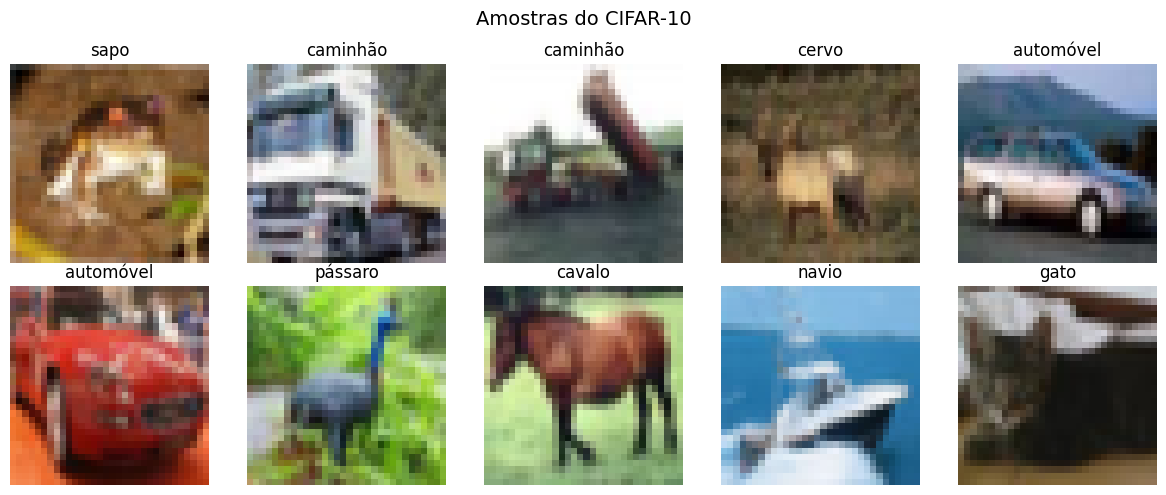

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow:", tf.__version__)

CLASS_NAMES = ['avião','automóvel','pássaro','gato','cervo',
               'cachorro','sapo','cavalo','navio','caminhão']

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print(f"Treino: {x_train.shape}  |  Teste: {x_test.shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]])
    ax.axis('off')
plt.suptitle('Amostras do CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()


## 2. Funções auxiliares

In [2]:
def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric, label in zip(axes, ['accuracy','loss'], ['Acurácia','Loss']):
        ax.plot(hist.history[metric],     label='Treino')
        ax.plot(hist.history[f'val_{metric}'], label='Validação')
        ax.set_title(f'{title} – {label}')
        ax.set_xlabel('Épocas')
        ax.set_ylabel(label)
        ax.legend()
    plt.tight_layout()
    plt.show()

def evaluate(model, name):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    y_true = y_test.flatten()
    print(f"\n{'='*55}")
    print(f"  Relatório – {name}")
    print('='*55)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"  Acurácia no teste: {acc:.4f}  |  Loss: {loss:.4f}")
    return acc, y_pred

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


## 3. A – CNN Simples (baseline)

In [3]:
# Arquitetura: 2 blocos Conv+Pool → Flatten → Dense
# Justificativa: ponto de referência mínimo para comparação

model_A = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='CNN_Simples')

model_A.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_A.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Simples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4376 - loss: 1.5493 - val_accuracy: 0.5652 - val_loss: 1.2331
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5649 - loss: 1.2178 - val_accuracy: 0.6214 - val_loss: 1.0648
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6212 - loss: 1.0725 - val_accuracy: 0.6642 - val_loss: 0.9664
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6543 - loss: 0.9807 - val_accuracy: 0.6802 - val_loss: 0.9187
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6771 - loss: 0.9120 - val_accuracy: 0.6892 - val_loss: 0.8887
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7017 - loss: 0.8458 - val_accuracy: 0.6998 - val_loss: 0.8935
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7219 - loss: 0.7890 - val_accuracy: 0.7062 - val_loss: 0.8528
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7372 - loss: 0.7413 - val_accuracy: 0

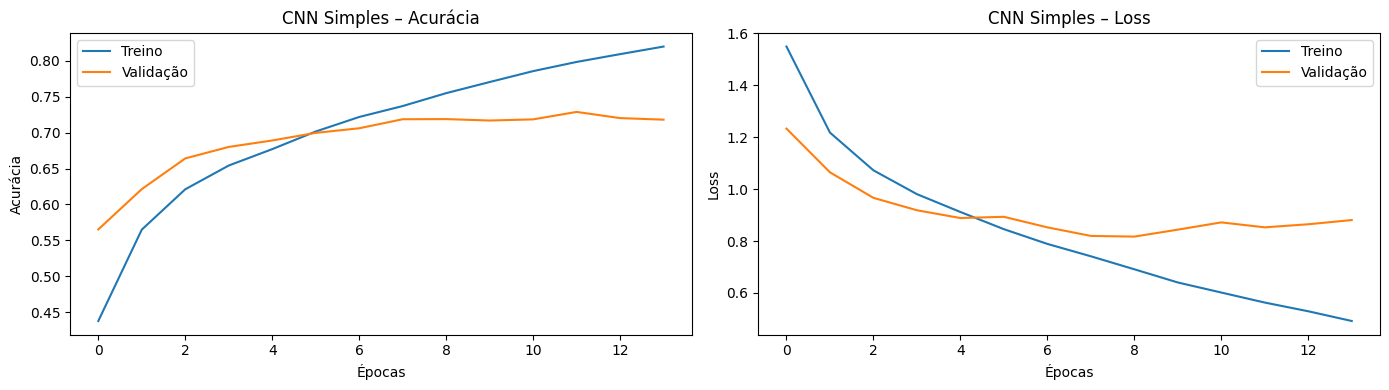

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

  Relatório – CNN Simples
              precision    recall  f1-score   support

       avião     0.7485    0.7380    0.7432      1000
   automóvel     0.8228    0.8360    0.8294      1000
     pássaro     0.7112    0.4900    0.5802      1000
        gato     0.4737    0.5940    0.5271      1000
       cervo     0.6309    0.7110    0.6685      1000
    cachorro     0.5747    0.6620    0.6152      1000
        sapo     0.8161    0.7500    0.7817      1000
      cavalo     0.8228    0.7150    0.7651      1000
       navio     0.7930    0.8200    0.8063      1000
    caminhão     0.8218    0.7840    0.8025      1000

    accuracy                         0.7100     10000
   macro avg     0.7215    0.7100    0.7119     10000
weighted avg     0.7215    0.7100    0.7119     10000

  Acurácia no teste: 0.7100  |  Loss: 0.8536


In [4]:
hist_A = model_A.fit(x_train, y_train, epochs=30, batch_size=64,
                     validation_split=0.1, callbacks=[early_stop], verbose=1)
plot_history(hist_A, 'CNN Simples')
acc_A, pred_A = evaluate(model_A, 'CNN Simples')


## 4. B – CNN Profunda (3 blocos + BatchNorm)

In [5]:
# Arquitetura: 3 blocos Conv+BN+Pool → GlobalAvgPool → Dense
# Justificativa: BatchNorm acelera convergência; GlobalAvgPool reduz overfitting

model_B = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Profunda')

model_B.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_B.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.4856 - loss: 1.4200 - val_accuracy: 0.4678 - val_loss: 1.5084
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6311 - loss: 1.0365 - val_accuracy: 0.5352 - val_loss: 1.3122
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6901 - loss: 0.8783 - val_accuracy: 0.6274 - val_loss: 1.0381
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7304 - loss: 0.7675 - val_accuracy: 0.6256 - val_loss: 1.0584
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7588 - loss: 0.6889 - val_accuracy: 0.7016 - val_loss: 0.8818


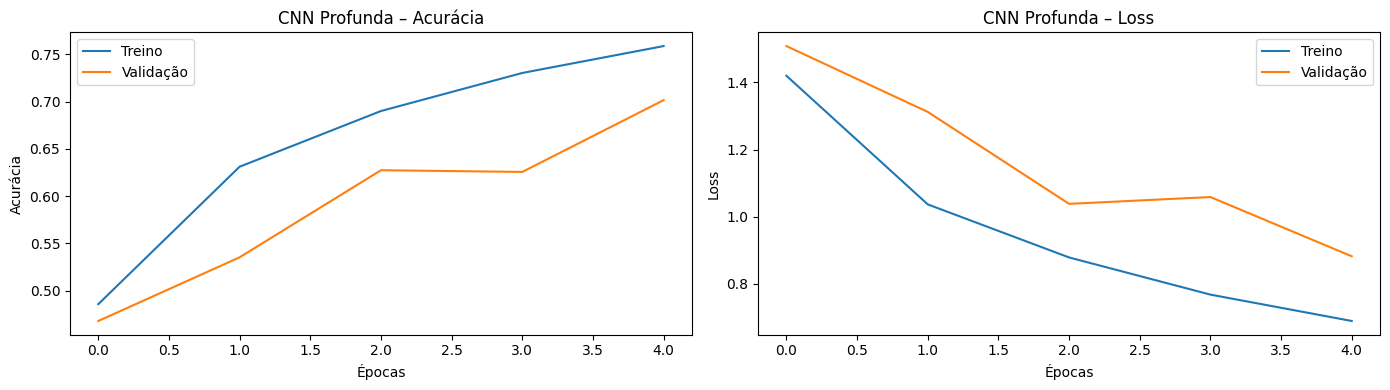

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

  Relatório – CNN Profunda
              precision    recall  f1-score   support

       avião     0.6178    0.2570    0.3630      1000
   automóvel     0.7495    0.3620    0.4882      1000
     pássaro     0.6163    0.1510    0.2426      1000
        gato     0.3228    0.4290    0.3684      1000
       cervo     0.3923    0.6280    0.4829      1000
    cachorro     0.7391    0.0680    0.1245      1000
        sapo     0.7405    0.4480    0.5583      1000
      cavalo     0.6563    0.5270    0.5846      1000
       navio     0.5737    0.7630    0.6549      1000
    caminhão     0.3004    0.9300    0.4541      1000

    accuracy                         0.4563     10000
   macro avg     0.5709    0.4563    0.4321     10000
weighted avg     0.5709    0.4563    0.4321     10000

  Acurácia no teste: 0.4563  |  Loss: 1.5223


In [6]:
hist_B = model_B.fit(x_train, y_train, epochs=30, batch_size=64,
                     validation_split=0.1, callbacks=[early_stop], verbose=1)
plot_history(hist_B, 'CNN Profunda')
acc_B, pred_B = evaluate(model_B, 'CNN Profunda')


## 5. C – CNN com Data Augmentation

In [7]:
# Arquitetura: Augmentation → 3 blocos Conv+Pool → Dense
# Justificativa: aumenta artificialmente o dataset, reduz overfitting em imagens

data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model_C = models.Sequential([
    data_aug,
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN_DataAug')

model_C.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_C.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_DataAug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3627 - loss: 1.7445 - val_accuracy: 0.4616 - val_loss: 1.4859
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4837 - loss: 1.4334 - val_accuracy: 0.5560 - val_loss: 1.2228
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5336 - loss: 1.3115 - val_accuracy: 0.6114 - val_loss: 1.0909
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5643 - loss: 1.2278 - val_accuracy: 0.6256 - val_loss: 1.0502
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5876 - loss: 1.1664 - val_accuracy: 0.6644 - val_loss: 0.9559


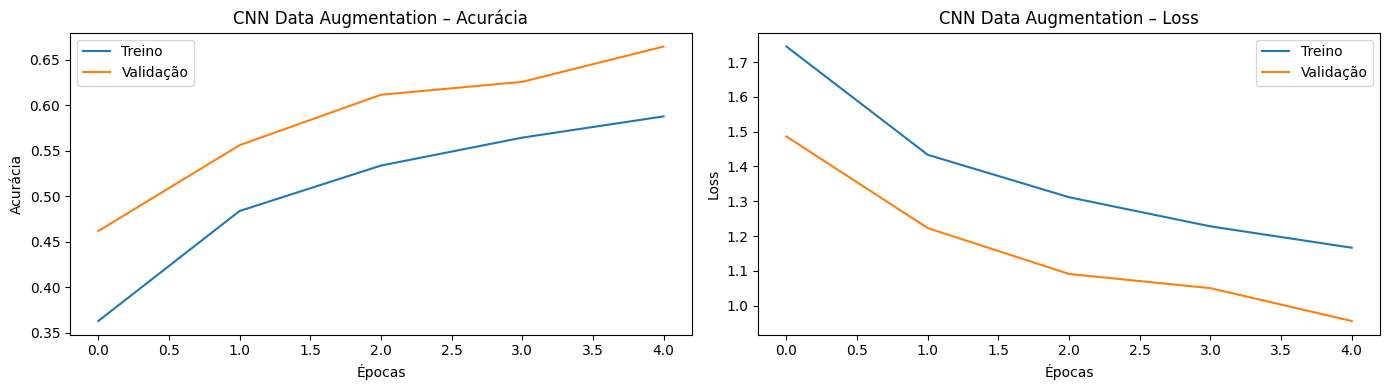

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

  Relatório – CNN Data Augmentation
              precision    recall  f1-score   support

       avião     0.5670    0.3810    0.4557      1000
   automóvel     0.4768    0.7280    0.5762      1000
     pássaro     0.4476    0.1920    0.2687      1000
        gato     0.4625    0.1420    0.2173      1000
       cervo     0.5184    0.1690    0.2549      1000
    cachorro     0.5148    0.3130    0.3893      1000
        sapo     0.3606    0.7860    0.4943      1000
      cavalo     0.4853    0.6100    0.5405      1000
       navio     0.5508    0.5850    0.5674      1000
    caminhão     0.4044    0.6600    0.5015      1000

    accuracy                         0.4566     10000
   macro avg     0.4788    0.4566    0.4266     10000
weighted avg     0.4788    0.4566    0.4266     10000

  Acurácia no teste: 0.4566  |  Loss: 1.4882


In [8]:
hist_C = model_C.fit(x_train, y_train, epochs=30, batch_size=64,
                     validation_split=0.1, callbacks=[early_stop], verbose=1)
plot_history(hist_C, 'CNN Data Augmentation')
acc_C, pred_C = evaluate(model_C, 'CNN Data Augmentation')


## 6. Comparação dos três modelos

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics(pred):
    y_true = y_test.flatten()
    return dict(
        precisao = precision_score(y_true, pred, average='weighted'),
        recall   = recall_score(y_true, pred, average='weighted'),
        f1       = f1_score(y_true, pred, average='weighted'),
    )

m_A, m_B, m_C = metrics(pred_A), metrics(pred_B), metrics(pred_C)

print(f"{'Modelo':<25} {'Acurácia':>10} {'Precisão':>10} {'Recall':>10} {'F1-Score':>10}")
print('-'*65)
for name, acc, m in [('CNN Simples', acc_A, m_A),
                      ('CNN Profunda (BN)', acc_B, m_B),
                      ('CNN Data Aug', acc_C, m_C)]:
    print(f"{name:<25} {acc:>10.4f} {m['precisao']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")


Modelo                      Acurácia   Precisão     Recall   F1-Score
-----------------------------------------------------------------
CNN Simples                   0.7100     0.7215     0.7100     0.7119
CNN Profunda (BN)             0.4563     0.5709     0.4563     0.4321
CNN Data Aug                  0.4566     0.4788     0.4566     0.4266


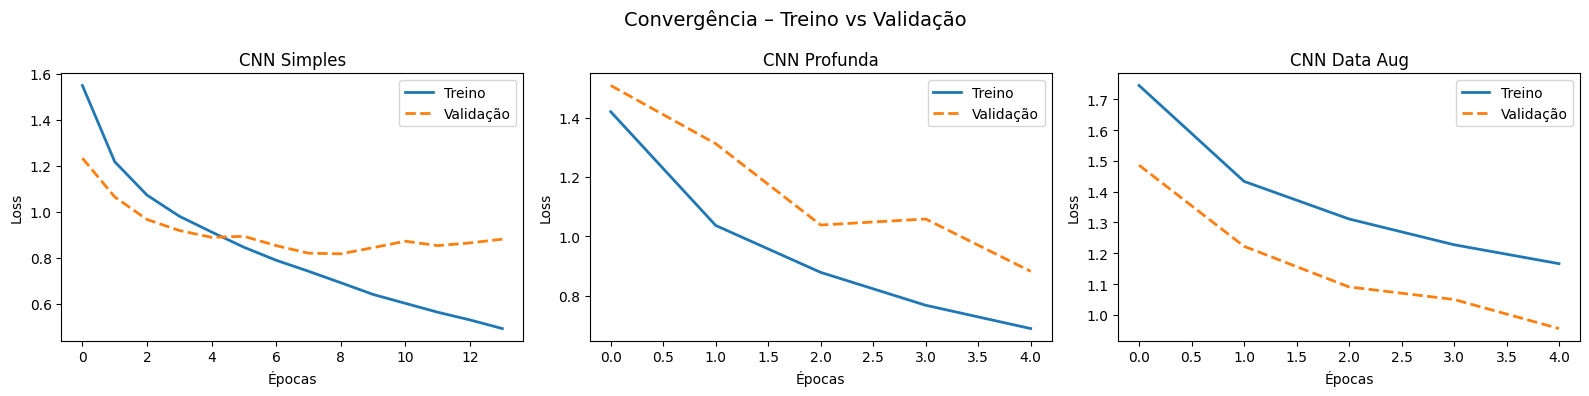

In [10]:
# Gráfico comparativo de loss – treino vs validação
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, hist, title in zip(axes,
    [hist_A, hist_B, hist_C],
    ['CNN Simples', 'CNN Profunda', 'CNN Data Aug']):
    ax.plot(hist.history['loss'],     label='Treino', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Validação', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Convergência – Treino vs Validação', fontsize=14)
plt.tight_layout()
plt.show()
